## Iris dataset using K-means clustering

In [2]:
# Edit all the Mardown cells below with the appropriate information 
# Run all cells, containing your code 
# Save this Jupyter with the outputs of your executed cells
# PS: Save again the notebook with this outcome.
# PSPS: Don't forget to include the dataset in your submission

**Team:**
* Luyao Li

**Course:** CISD 43 – BIG DATA (Spring, 2025)

### Problem Statement
* This project aims to analyze and model the species of iris flowers using the classic Iris dataset. The dataset contains 150 samples, each with four features: sepal length, sepal width, petal length, and petal width, along with the corresponding flower species (Setosa, Versicolor, or Virginica). The objective is to explore various machine learning methods to understand the structure of the data and to perform prediction and clustering on the flower species.
    
* **Keywords:** K-means Clustering
	

### Required packages

* Add instructions to install the required packages


In [16]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_toolkits # It provides additional functionality and tools that extend the capabilities of Matplotlib
# for more advanced plotting tasks. We will use it for 3D plotting.

# Load the dataset
file_path="iris.csv"
df= pd.read_csv(file_path)

# Display first few rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [22]:
# Check for missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

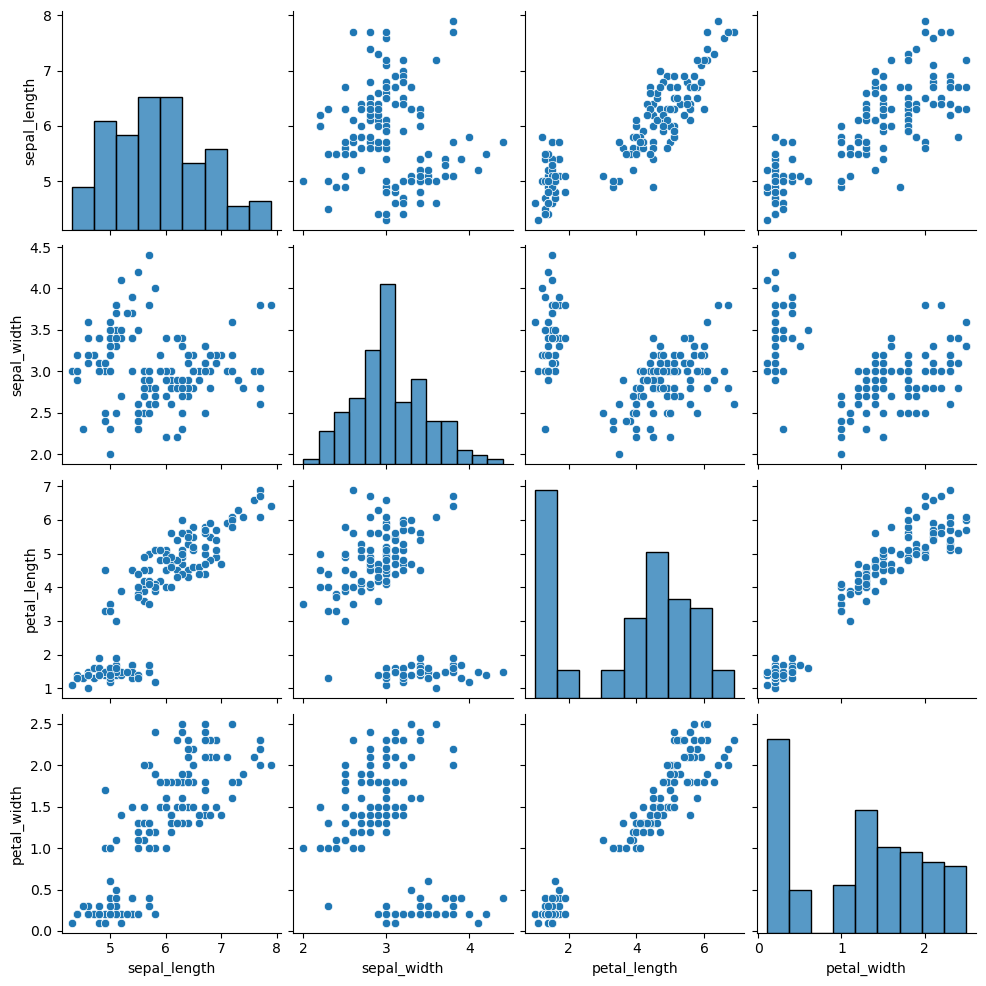

In [24]:
# This will automatically create not just histograms of all the columns but also
# correllation scatter plots
sns.pairplot(df)
plt.show() #plot will not show up without this line. 

### Methodology

1. Explan your big data metodology



2. Introduce the topics you used in your project
 * Model 1
    * KNN
 
 * Model 2
    * Linear Regression
 

### Your code starts here

In [41]:
#Load Libraries
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [49]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

In [51]:
scaler = StandardScaler() # KMeans Initialization: This line initializes a KMeans clustering model object.
X_scaled = scaler.fit_transform(X)  # This line fits the KMeans model to the data and 
                                   # simultaneously assigns each data point to a cluster.

In [53]:
#Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [55]:
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f'Silhouette Score: {silhouette_avg:.3f}')

Silhouette Score: 0.480


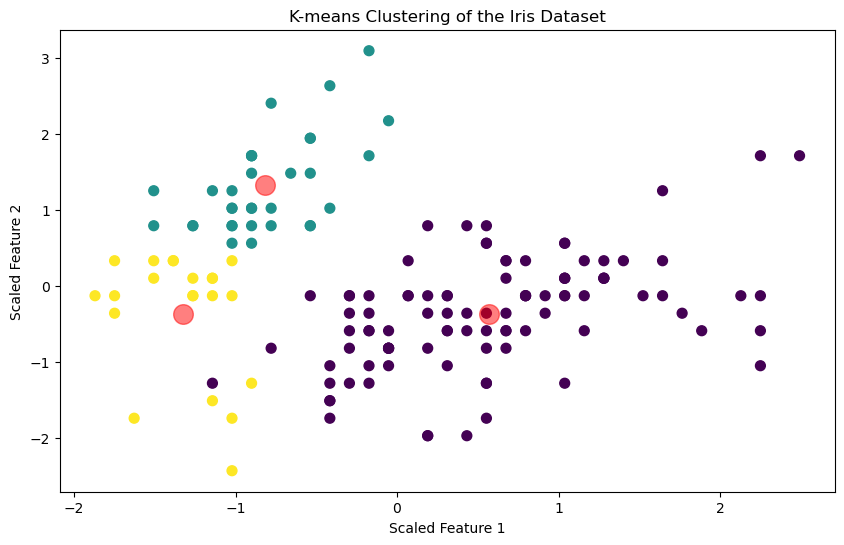

In [59]:
# Visualize the clustering (using the first two features)
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.title('K-means Clustering of the Iris Dataset')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.show()

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
#iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


#### Let's add a new column named 'Species' to the DataFrame iris_df.

pd.Categorical.from_codes(): This function creates a categorical object from codes and categories. 

iris.target: 
- This is the array of target labels from the Iris dataset. Each label corresponds to a particular species of Iris flower.

iris.target_names: 
- This is an array containing the names of the Iris species.

In [66]:
iris_df['Species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


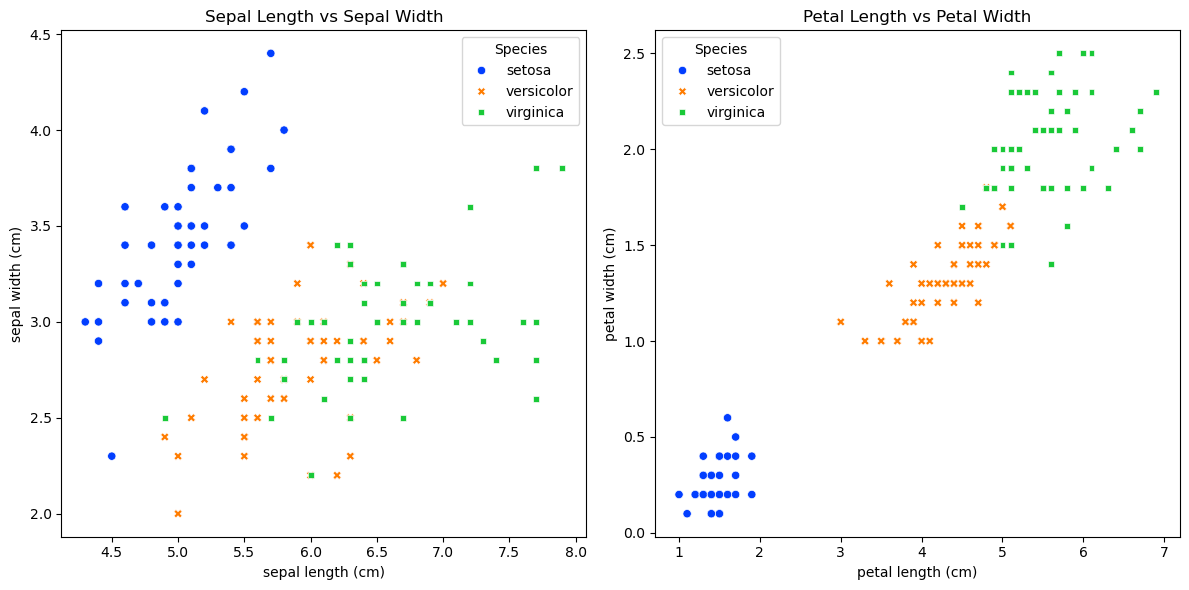

In [68]:
# Plotting Sepal Length vs Sepal Width
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='Species', data=iris_df, style='Species', palette='bright')
plt.title('Sepal Length vs Sepal Width')

# Plotting Petal Length vs Petal Width
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='Species', data=iris_df, style='Species', palette='bright')
plt.title('Petal Length vs Petal Width')

plt.tight_layout()
plt.show()

Verify the number of K using the Elbow method

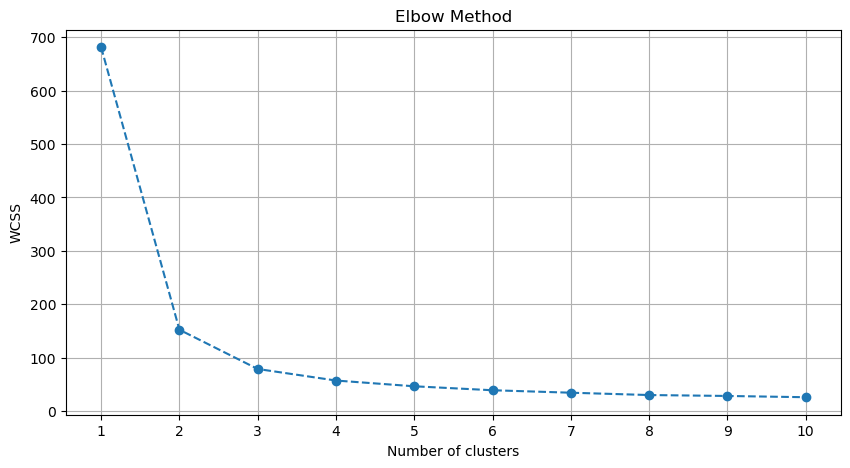

In [72]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
# Load the Iris dataset
iris = load_iris()
X = iris.data

# Calculating WCSS for different numbers of clusters
wcss = []
for i in range(1, 11):  # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the results onto a line graph to observe 'The Elbow'
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')  # Within cluster sum of squares
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Conclusions


In the Iris dataset, the elbow point appears approximately at k = 3.

- "This aligns with the actual number of iris species in the dataset."

- The Iris dataset originally contains three species: Setosa, Versicolor, and Virginica.

- "Therefore, we can conclude that the data naturally clusters into three groups, and the KMeans clustering algorithm performs well in this case."










###  References
   - Academic : Example 1 - K-means clustering - Iris Dataset
   - Online (if any)
	

### Credits

- If you use and/or adapt your code from existing projects, you must provide links and acknowldge the authors. 
> *This code is based on .... (if any)*Example 1 - K-means clustering - Iris Dataset

In [ ]:
# End of Project